# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

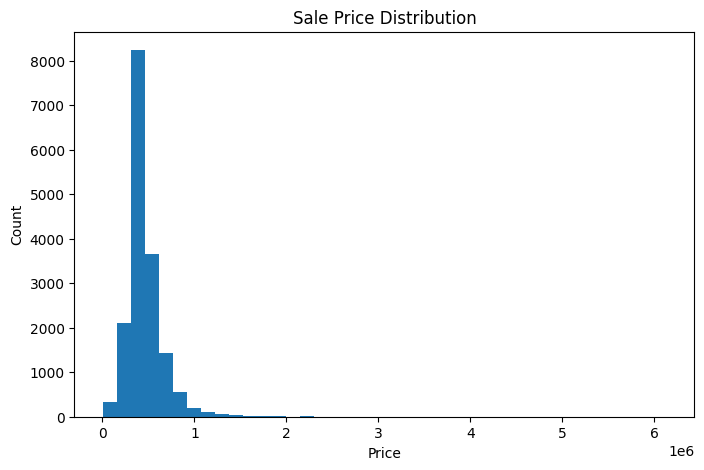

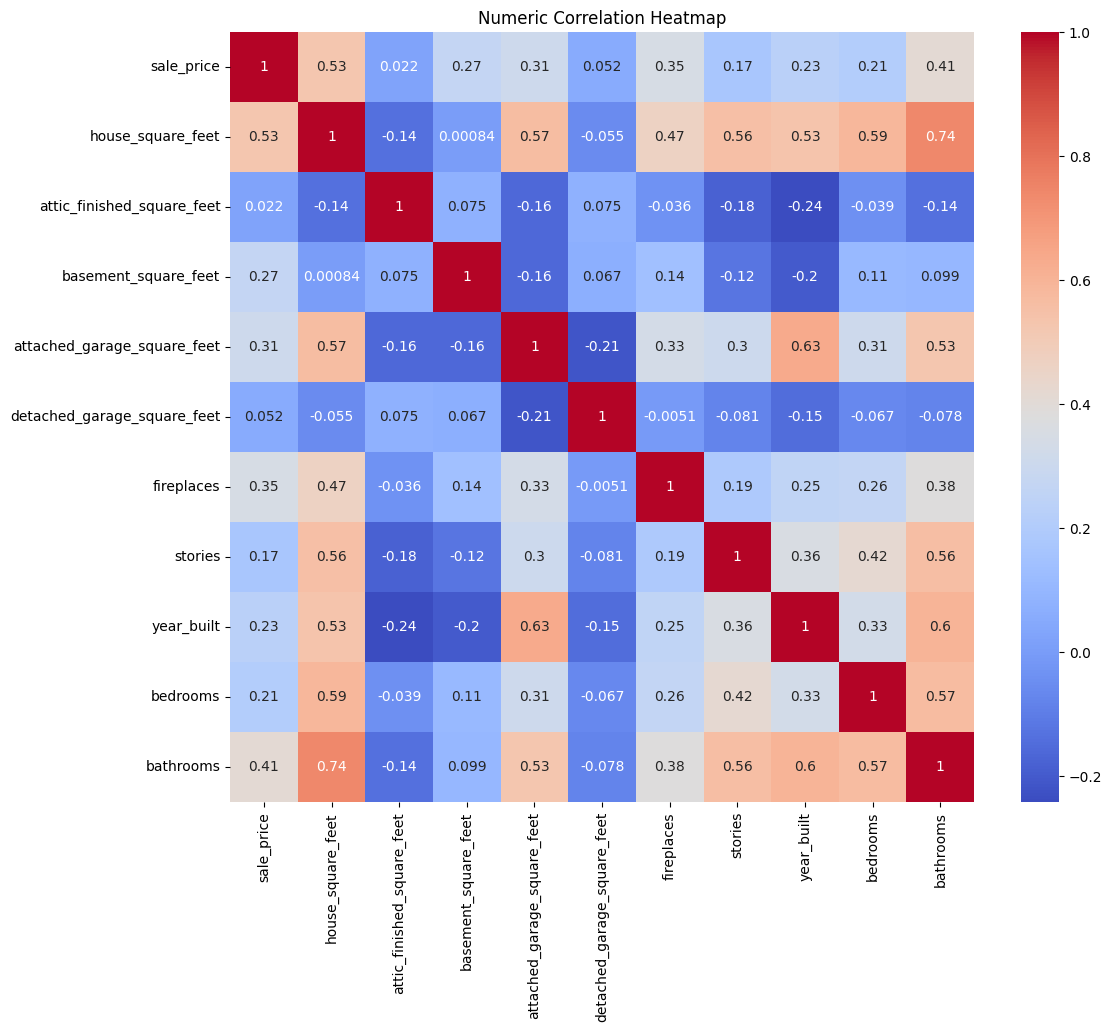

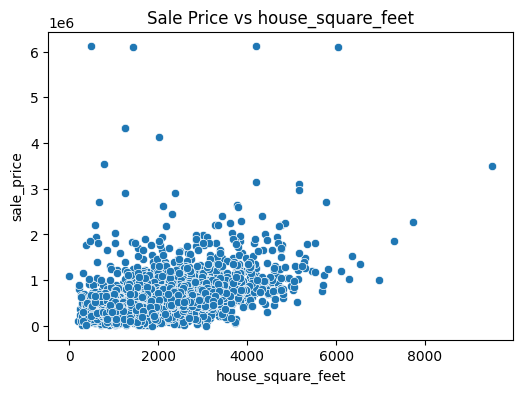

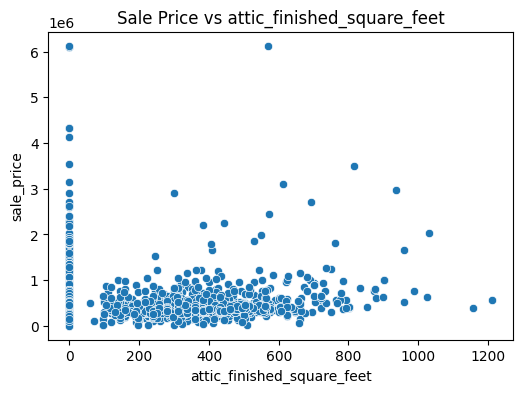

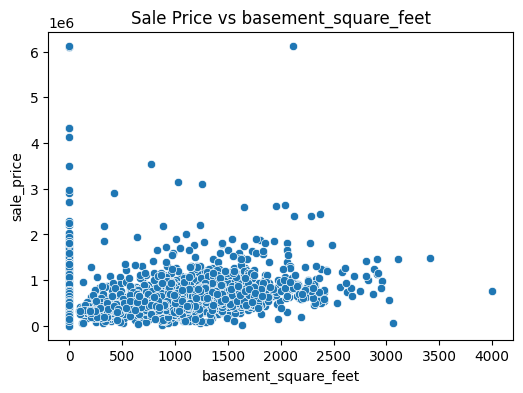

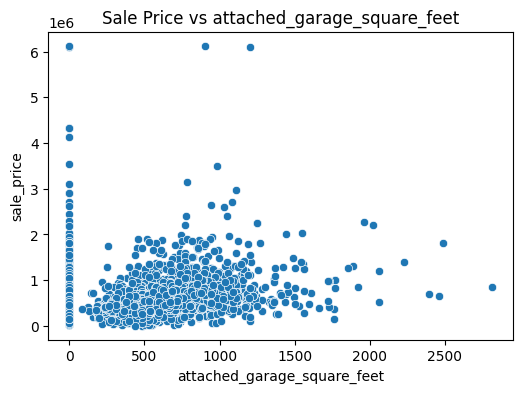

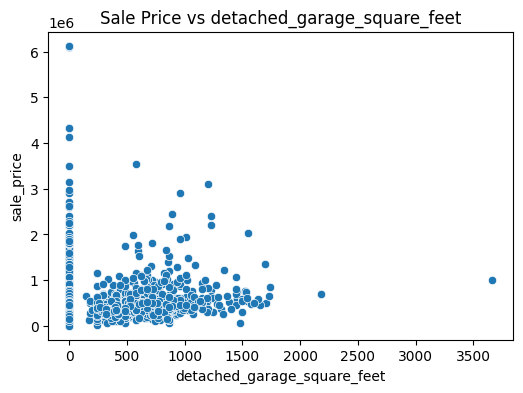

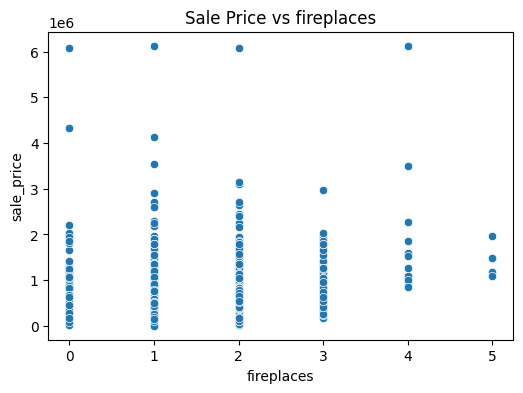

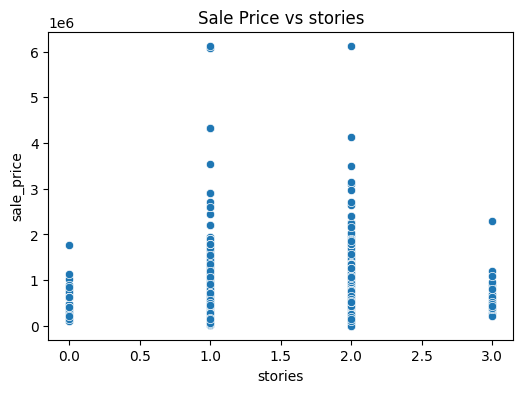

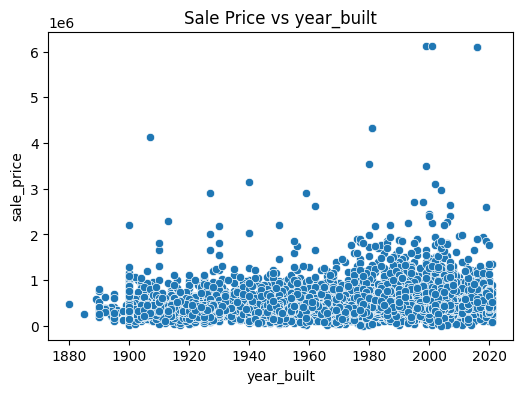

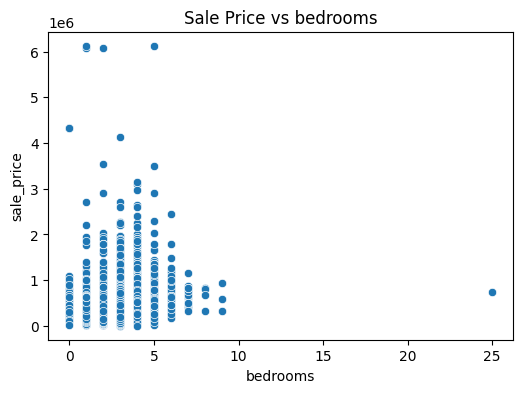

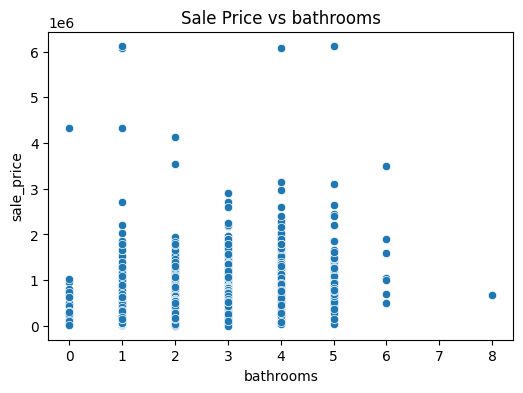

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'

In [2]:
# ============================================
# HEDONIC PRICING FULL ANALYSIS PIPELINE
# Single Jupyter Cell — Copy & Run
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

# ---------------------------------------------------
# 1. LOAD & CLEAN DATA
# ---------------------------------------------------

df = pd.read_csv("/content/pierce_county_house_sales.csv", parse_dates=["sale_date"])

# Clean missing prices
df = df.dropna(subset=["sale_price"])

# Convert to categorical
categorical_cols = [
    "hvac_description","exterior","interior","roof_cover",
    "waterfront_type","view_quality","utility_sewer"
]
for col in categorical_cols:
    df[col] = df[col].replace("", np.nan).astype("category")

# ---------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS
# ---------------------------------------------------

plt.figure(figsize=(8,5))
plt.hist(df["sale_price"], bins=40)
plt.title("Sale Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Correlation heatmap of numerics
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Numeric Correlation Heatmap")
plt.show()

# Scatterplots vs price
for col in num_cols:
    if col != "sale_price":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df["sale_price"])
        plt.title(f"Sale Price vs {col}")
        plt.show()

# ---------------------------------------------------
# 3. TRANSFORM VARIABLES
# ---------------------------------------------------

df_model = df.copy()

# Log-transform skewed numeric fields
df_model["log_price"] = np.log(df["sale_price"])
df_model["log_sqft"] = np.log1p(df["house_square_feet"])

# One-hot encode categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

# ---------------------------------------------------
# 4. TRAIN/TEST SPLIT
# ---------------------------------------------------

X = df_model.drop(columns=["sale_price", "log_price"])
y = df_model["sale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# 5. SIMPLE LINEAR MODEL + EVALUATION
# ---------------------------------------------------

def evaluate(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)
    return {
        "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE_test":  np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2_train": r2_score(y_train, pred_train),
        "R2_test":  r2_score(y_test, pred_test)
    }

lin_simple = LinearRegression()
lin_simple.fit(X_train, y_train)

print("===== SIMPLE LINEAR MODEL =====")
print(evaluate(lin_simple, X_train, y_train, X_test, y_test))

# ---------------------------------------------------
# 6. PARTIAL CORRELATION PLOTS
# ---------------------------------------------------

model_sm = sm.OLS(y_train, sm.add_constant(X_train[num_cols.drop("sale_price")]), missing="drop").fit()

fig = sm.graphics.plot_partregress_grid(model_sm)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 7. COMPLEX MODEL (INTERACTIONS + POLYNOMIALS)
# ---------------------------------------------------

df_model["sqft_sq"] = df["house_square_feet"]**2
df_model["beds_x_baths"] = df["bedrooms"] * df["bathrooms"]

X = df_model.drop(columns=["sale_price", "log_price"])
y = df_model["sale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_complex = LinearRegression()
lin_complex.fit(X_train, y_train)

print("\n===== COMPLEX MODEL =====")
print(evaluate(lin_complex, X_train, y_train, X_test, y_test))

# ---------------------------------------------------
# 8. LASSO REGRESSION (FEATURE SELECTION)
# ---------------------------------------------------

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

print("\n===== LASSO REGULARIZATION =====")
print(evaluate(lasso, X_train, y_train, X_test, y_test))

selected_features = pd.Series(lasso.coef_, index=X.columns)
print("\nFEATURES SELECTED BY LASSO:")
print(selected_features[selected_features != 0].sort_values())

# ---------------------------------------------------
# END OF SINGLE-CELL PIPELINE
# ---------------------------------------------------